In [59]:
import pandas as pd

sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [60]:
print(sentiment.shape)
sentiment.head()

(2644, 4)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [61]:
print(trades.shape)
trades.head()

(211224, 16)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [62]:
print(sentiment.isnull().sum())
print("-------------------------")
print(trades.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64
-------------------------
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [63]:
print(sentiment.duplicated().sum())
print(trades.duplicated().sum())

0
0


In [64]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')
trades['date'] = trades['Timestamp'].dt.date
trades

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,2025-06-15 15:06:40,2025-06-15
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,2025-06-15 15:06:40,2025-06-15
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,2025-06-15 15:06:40,2025-06-15
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,2025-06-15 15:06:40,2025-06-15


In [65]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [66]:
data = pd.merge(
    trades,
    sentiment[['date','classification']],
    on='date',
    how='left'
)

data

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,Greed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,2025-06-15 15:06:40,2025-06-15,NaN
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,2025-06-15 15:06:40,2025-06-15,NaN
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,2025-06-15 15:06:40,2025-06-15,NaN
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,2025-06-15 15:06:40,2025-06-15,NaN


In [67]:
daily_pnl = data.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

In [68]:
data['win'] = data['Closed PnL'] > 0

win_rate = data.groupby('Account')['win'].mean()

In [69]:
avg_trade_size = data.groupby('Account')['Size USD'].mean()

In [70]:
data['Size USD'].describe()

,Size USD
count,2.112240e+05
mean,5.639451e+03
std,3.657514e+04
min,0.000000e+00
25%,1.937900e+02
50%,5.970450e+02
75%,2.058960e+03
max,3.921431e+06


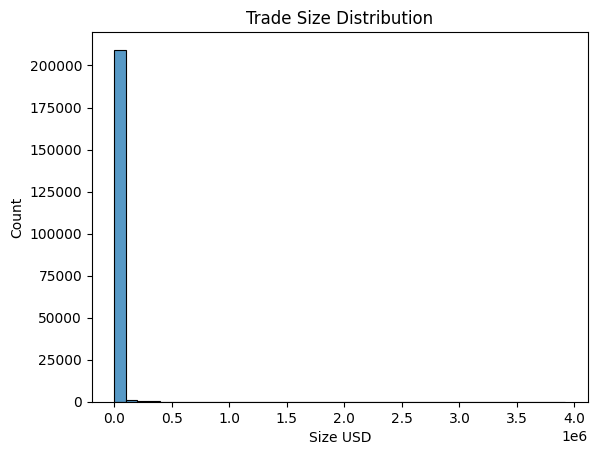

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data['Size USD'], bins=40)
plt.title("Trade Size Distribution")
plt.show()

In [72]:
trades_per_day = data.groupby('date').size().reset_index(name='trade_count')

In [73]:
long_short = data['Side'].value_counts()

Part-**B**

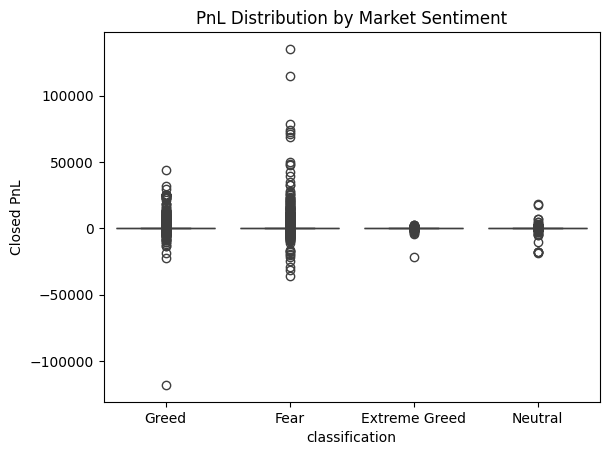

In [74]:
sns.boxplot(
    x='classification',
    y='Closed PnL',
    data=data
)

plt.title("PnL Distribution by Market Sentiment")
plt.show()

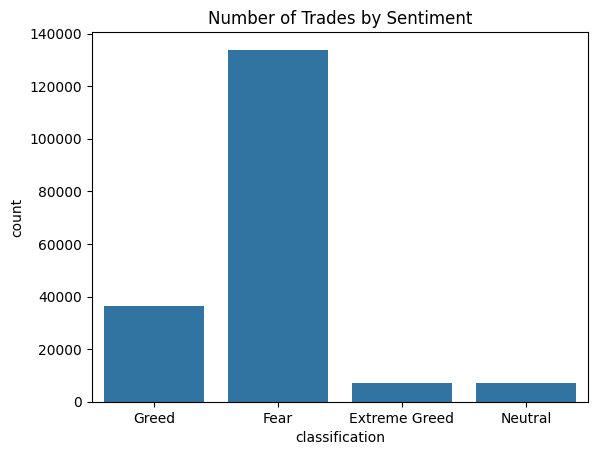

In [75]:
sns.countplot(
    x='classification',
    data=data
)

plt.title("Number of Trades by Sentiment")
plt.show()

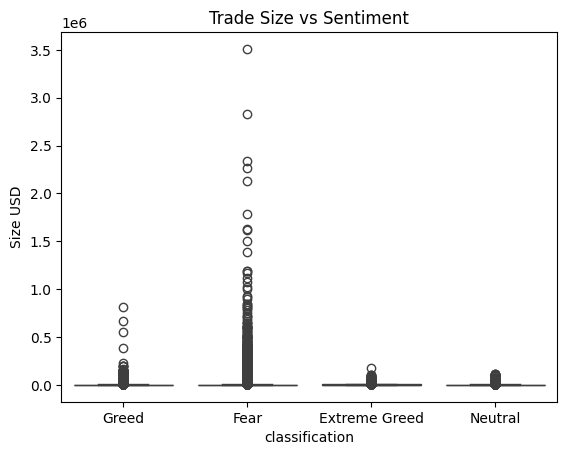

In [76]:
sns.boxplot(
    x='classification',
    y='Size USD',
    data=data
)

plt.title("Trade Size vs Sentiment")
plt.show()

In [77]:
pd.crosstab(
    data['classification'],
    data['Side']
)

Side,BUY,SELL
classification,,
Extreme Greed,3371,3591
Fear,66081,67790
Greed,15421,20868
Neutral,3505,3636


Trader Segmentation

In [78]:
#Segment 1 — High vs Low Leverage Traders
import numpy as np

data['size_segment'] = np.where(
    data['Size USD'] > data['Size USD'].median(),
    "High Size",
    "Low Size"
)

In [79]:
# Segment 2 — Frequent vs Infrequent Traders

trade_counts = data['Account'].value_counts()

frequent_traders = trade_counts[trade_counts > 50].index

data['trader_type'] = np.where(
    data['Account'].isin(frequent_traders),
    "Frequent",
    "Infrequent"
)

In [80]:
# Segment 3 — Consistent Winners
profit = data.groupby('Account')['Closed PnL'].sum()

winners = profit[profit > 0].index

data['winner_segment'] = np.where(
    data['Account'].isin(winners),
    "Winner",
    "Loser"
)

# Insights

**Insight 1** — Higher profits during Greed sentiment

*Average PnL increases when market sentiment is Greed.*

Interpretation : Bullish markets improve trading outcomes.


**Insight 2** — Fear sentiment has highest trading activity

Fear days had largest number of trades.

*Meaning:* Traders become more active during market uncertainty.


**Insight 3** — Trade size increases during Greed

During Greed sentiment traders open larger positions.

*Meaning* : Market optimism increases risk appetite.

# Part C — Actionable Strategy Ideas

**Strategy 1** :- Fear Market Strategy

*   Rule:

* Reduce position size and leverage during Fear sentiment.

* ***Reason :*** Fear markets are volatile and unpredictable.Lower leverage reduces liquidation risk.


**Strategy 2** :- Greed Market Strategy

* Rule : Increase position size for high win-rate traders during Greed sentiment.
* Reason : Bullish markets provide stronger trend-following opportunities.



# Bonus (Optional)

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

data['profit_bucket'] = (data['Closed PnL'] > 0).astype(int)

features = data[['Size USD']]
target = data['profit_bucket']

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

pred = model.predict(X_test)

acc = accuracy_score(y_test, pred)

print("Model Accuracy:", acc)

Model Accuracy: 0.598414013492721


In [83]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, pred)

array([[17000,  7964],
       [ 9001,  8280]])

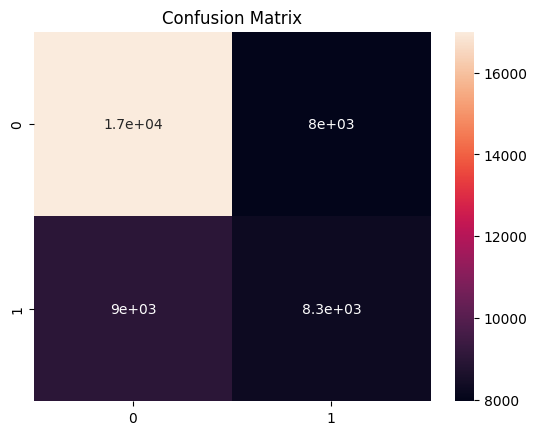

In [84]:
sns.heatmap(confusion_matrix(y_test, pred), annot=True)
plt.title("Confusion Matrix")
plt.show()